<a href="https://colab.research.google.com/github/abhiniveshg0-max/DEEP-LEARNING/blob/main/Experiment%203%20part%20c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np

### Load and Preprocess CIFAR-10 Dataset

We will load the CIFAR-10 dataset, normalize the pixel values to be between 0 and 1, and convert the labels to one-hot encoded vectors. We'll also split the training data into training and validation sets.

In [ ]:
# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

# Split training data into training and validation sets
x_train, x_val = x_train_full[5000:], x_train_full[:5000]
y_train, y_val = y_train_full[5000:], y_train_full[:5000]

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

114712576/170498071 ━━━━━━━━━━━━━━━━━━━━ 5:31 6us/step

### Define and Compile the CNN Model

Here, we define a simple CNN architecture using Keras Sequential API. This model will consist of convolutional layers, pooling layers, and dense layers for classification. After defining the architecture, we compile the model with an optimizer, loss function, and metrics.

In [ ]:
# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

### Train and Evaluate the CNN Model

With the model architecture defined and compiled, and the dataset prepared, we can now train the model using the `model.fit()` method. After training, we will evaluate its performance on the test set and plot the training and validation accuracy and loss over epochs.

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.8728 - loss: 0.3555 - val_accuracy: 0.7074 - val_loss: 1.0813
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 81ms/step - accuracy: 0.8817 - loss: 0.3318 - val_accuracy: 0.7194 - val_loss: 1.0559
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.8890 - loss: 0.3130 - val_accuracy: 0.7030 - val_loss: 1.1817
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 80ms/step - accuracy: 0.8951 - loss: 0.2918 - val_accuracy: 0.7032 - val_loss: 1.1867
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.9037 - loss: 0.2723 - val_accuracy: 0.7044 - val_loss: 1.2457
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 82ms/step - accuracy: 0.9063 - loss: 0.2613 - val_accuracy: 0.6906 - val_loss: 1.3597
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 80ms/step - accuracy: 0.9139 - loss: 0.2401 - val_accuracy: 0.7014 - val_loss: 1.3563
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.9154 - loss: 0.2320 - 

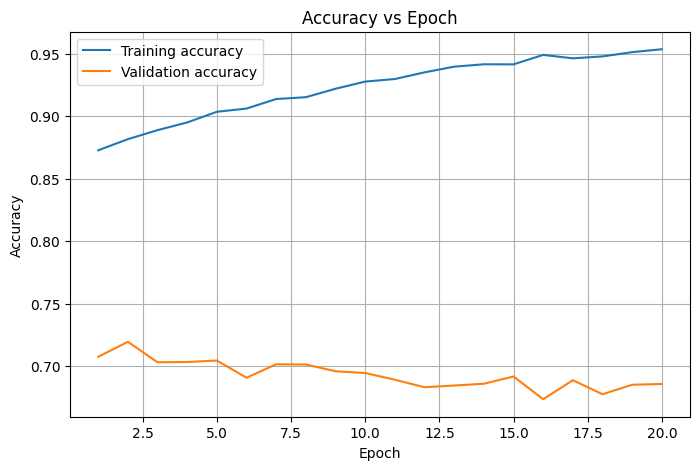

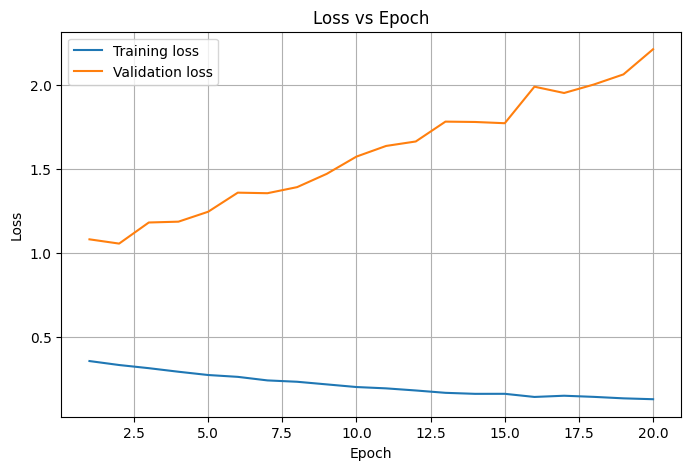

In [8]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# Train the CNN model
# -------------------------------------------------------------
EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# -------------------------------------------------------------
# Record: training / validation accuracy & loss (per epoch)
# -------------------------------------------------------------
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

print("\nFinal epoch results:")
print(f"Training accuracy   : {train_acc[-1]:.4f}")
print(f"Validation accuracy : {val_acc[-1]:.4f}")
print(f"Training loss       : {train_loss[-1]:.4f}")
print(f"Validation loss     : {val_loss[-1]:.4f}")

# -------------------------------------------------------------
# Record: testing accuracy (on unseen test set from Part A)
# -------------------------------------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Testing accuracy     : {test_acc:.4f}")
print(f"Testing loss         : {test_loss:.4f}")

# -------------------------------------------------------------
# Plot: Accuracy vs Epoch
# -------------------------------------------------------------
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_vs_epoch.png')
plt.show()

# -------------------------------------------------------------
# Plot: Loss vs Epoch
# -------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_vs_epoch.png')
plt.show()